# Clusterização

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans

In [4]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [10]:
df['Gender'] = df['Gender'].replace(['Male', 'Female'], [0, 1])

In [11]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,0,19,15,39
1,2,0,21,15,81
2,3,1,20,16,6
3,4,1,23,16,77
4,5,1,31,17,40


# Pontuação de silhueta 

In [13]:
from sklearn.metrics import silhouette_score

for k in range (2,10):
    kmeans = KMeans(n_clusters=k)
    labels = kmeans.fit_predict(df)
    score = silhouette_score(df, labels)
    print(k, score)

2 0.4793049017423563
3 0.37109951060125956
4 0.42245261332521894
5 0.4129419301414886
6 0.4136658769610973
7 0.36940351968975327
8 0.3715315233867053
9 0.3679612363522925


# Cotovelo

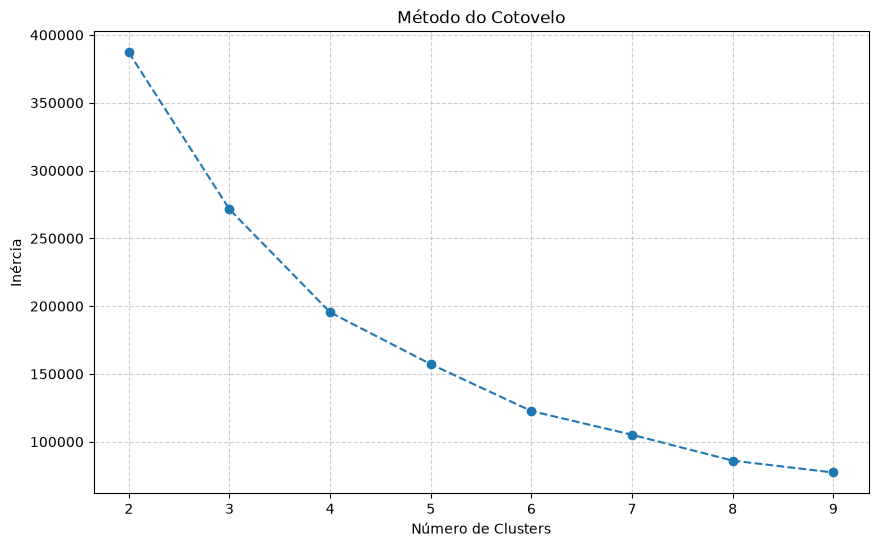

In [14]:
inercia_lista = []
intervalo = range (2,10)

for k in intervalo:
    kmeans_temp = KMeans(n_clusters=k, n_init=10)
    kmeans_temp.fit(df)
    inercia_lista.append(kmeans_temp.inertia_)

plt.figure(figsize=(10,6))
plt.plot(intervalo, inercia_lista, marker='o', linestyle = '--')

plt.title ('Método do Cotovelo')
plt.xlabel('Número de Clusters')
plt.ylabel('Inércia')
plt.xticks(intervalo)
plt.grid(True, linestyle = '--', alpha=0.6)
plt.show()

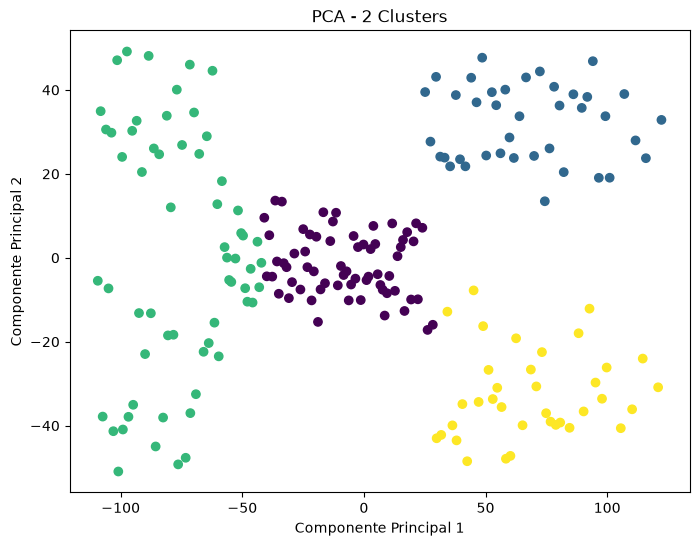

In [15]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca = PCA(n_components=2)
df_pca = pca.fit_transform(df)

kmeans = KMeans(n_clusters=4, n_init=10)
kmeans.fit(df_pca)
labels2 = kmeans.predict(df_pca)


plt.figure(figsize=(8,6))
plt.scatter(df_pca[:,0], df_pca[:,1], c=labels2)
plt.title('PCA - 2 Clusters')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

In [16]:
df['Cluster'] = labels2

In [17]:
df.groupby('Cluster').mean()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,,
0,93.546875,0.578125,42.546875,58.125000,49.343750
1,162.000000,0.538462,32.692308,86.538462,82.128205
2,31.000000,0.606557,37.754098,30.360656,49.754098
3,164.000000,0.472222,40.805556,87.916667,17.888889
